In [7]:
import numpy as np
X = np.array([
    [20, 6, 2],
    [16, 3, 6],
    [27, 6, 2],
    [19, 1, 2],
    [24, 4, 2],
    [22, 1, 5],
    [15, 4, 2],
    [18, 4, 2],
    [21, 1, 4],
    [16, 2, 4]])
y = np.array([386, 289, 393, 110, 280, 167, 271, 274, 148, 198])

print("Dimensionality:", X.shape[1])
print("Number of vectors:", X.shape[0])

rank = np.linalg.matrix_rank(X)
print("Rank of feature matrix:", rank)

cost = np.linalg.pinv(X) @ y

print("Candy Cost =", cost[0])
print("Mango Cost =", cost[1])
print("Milk Packet Cost =", cost[2])
print("Milk Packet Cost =", cost[2])

Dimensionality: 3
Number of vectors: 10
Rank of feature matrix: 3
Candy Cost = 1.0000000000000107
Mango Cost = 55.0
Milk Packet Cost = 18.000000000000007
Milk Packet Cost = 18.000000000000007


           Date Month  Day    Price     Open     High      Low   Volume  \
0  Jun 29, 2021   Jun  Tue  2081.85  2092.00  2126.90  2065.05    1.67M   
1  Jun 28, 2021   Jun  Mon  2077.75  2084.00  2112.45  2068.40  707.73K   
2  Jun 25, 2021   Jun  Fri  2068.85  2084.35  2088.50  2053.10  475.82K   
3  Jun 24, 2021   Jun  Thu  2072.95  2098.00  2098.00  2066.00  541.51K   
4  Jun 23, 2021   Jun  Wed  2078.25  2102.00  2111.40  2072.00  809.62K   

     Chg%  
0  0.0020  
1  0.0043  
2 -0.0020  
3 -0.0026  
4 -0.0023  
Mean (NumPy): 1560.6634538152612
Variance (NumPy): 58496.49239931613
Mean (User): 1560.6634538152598
Variance (User): 58496.49239931618
Average NumPy Time : 1.304149627685547e-05
Average User Time : 4.689693450927734e-05
Wednesday Mean Price: 1550.7060000000001
April Mean Price: 1698.9526315789474
Probability of Loss = 0.4979919678714859
Probability of Profit on Wednesday = 0.08433734939759036
Conditional Probability = 0.42


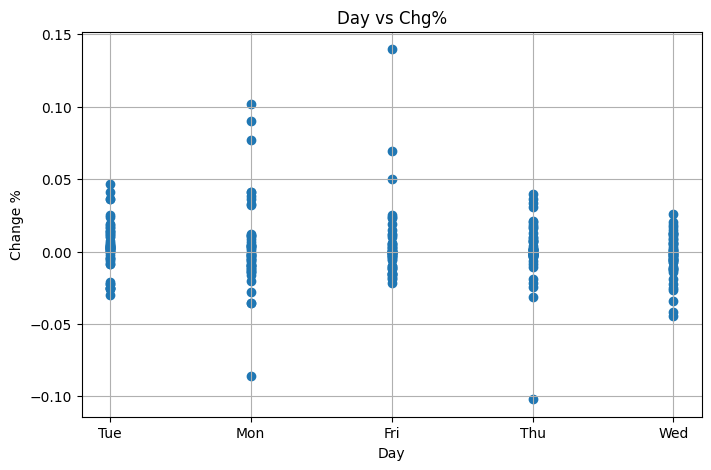

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

df = pd.read_excel("Downloads/Lab Session Data (1).xlsx",sheet_name="IRCTC Stock Price")
print(df.head())
price = df['Price'].values
print("Mean (NumPy):", np.mean(price))
print("Variance (NumPy):", np.var(price))
def mean(arr):
    return sum(arr) / len(arr)
def variance(arr):
    m = mean(arr)
    s = 0
    for i in arr:
        s += (i - m) ** 2
    return s / len(arr)
print("Mean (User):", mean(price))
print("Variance (User):",variance(price)) 
numpy_time = []
user_time = []
for i in range(10):
    start = time.time()
    np.mean(price)
    np.var(price)
    numpy_time.append(time.time() - start)
    start = time.time()
    mean(price)
    variance(price)
    user_time.append(time.time() - start)
print("Average NumPy Time :", np.mean(numpy_time))
print("Average User Time :", np.mean(user_time))
wednesday = df[df['Day'] == 'Wed']
print("Wednesday Mean Price:",np.mean(wednesday['Price']))
april = df[df['Month'] == 'Apr']
print("April Mean Price:",np.mean(april['Price']))
loss = df[df['Chg%'] < 0]
prob_loss = len(loss) / len(df)
print("Probability of Loss =", prob_loss)
wed_profit = df[(df['Day'] == 'Wed') &(df['Chg%'] > 0)]
prob_wed_profit = len(wed_profit) / len(df)
print("Probability of Profit on Wednesday =",prob_wed_profit)
conditional = len(wed_profit) / len(wednesday)
print("Conditional Probability =",conditional)
plt.figure(figsize=(8,5))
plt.scatter(df['Day'], df['Chg%'])
plt.xlabel("Day")
plt.ylabel("Change %")
plt.title("Day vs Chg%")
plt.grid(True)
plt.show()

In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("Downloads/Lab Session Data (1).xlsx",sheet_name="thyroid0387_UCI")

print("First 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)
print("\nDataset Information:")
print(df.info())
print("\nNumeric Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Range:")
for col in df.select_dtypes(include=np.number).columns:
    print(col,"Min =", df[col].min(),"Max =", df[col].max())
print("\nMean:")
print(df.mean(numeric_only=True))
print("\nVariance:")
print(df.var(numeric_only=True))
print("\nOutliers:")
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, ":", len(outliers))

First 5 Rows:
   Record ID  age sex on thyroxine query on thyroxine  \
0  840801013   29   F            f                  f   
1  840801014   29   F            f                  f   
2  840801042   41   F            f                  f   
3  840803046   36   F            f                  f   
4  840803047   32   F            f                  f   

  on antithyroid medication sick pregnant thyroid surgery I131 treatment  ...  \
0                         f    f        f               f              f  ...   
1                         f    f        f               f              f  ...   
2                         f    f        f               f              f  ...   
3                         f    f        f               f              f  ...   
4                         f    f        f               f              f  ...   

  TT4 measured  TT4 T4U measured T4U FTI measured FTI TBG measured TBG  \
0            f    ?            f   ?            f   ?            f   ?   
1       

In [8]:
import pandas as pd
import numpy as np

df = pd.read_excel("Downloads/Lab Session Data (1).xlsx",
                   sheet_name="thyroid0387_UCI")

# Select binary columns having t/f values
binary_cols = []

for col in df.columns:
    values = set(df[col].dropna().astype(str).str.lower().unique())
    if values.issubset({'t', 'f'}):
        binary_cols.append(col)

# Convert t/f to 1/0
binary_df = df[binary_cols].copy()

for col in binary_cols:
    binary_df[col] = binary_df[col].map({'t': 1, 'f': 0})

v1 = binary_df.iloc[0].values
v2 = binary_df.iloc[1].values

f11 = np.sum((v1 == 1) & (v2 == 1))
f10 = np.sum((v1 == 1) & (v2 == 0))
f01 = np.sum((v1 == 0) & (v2 == 1))
f00 = np.sum((v1 == 0) & (v2 == 0))

JC = f11 / (f11 + f10 + f01)
SMC = (f11 + f00) / (f11 + f10 + f01 + f00)

print("f11 =", f11)
print("f10 =", f10)
print("f01 =", f01)
print("f00 =", f00)

print("Jaccard Coefficient =", JC)
print("Simple Matching Coefficient =", SMC)

f11 = 1
f10 = 1
f01 = 2
f00 = 16
Jaccard Coefficient = 0.25
Simple Matching Coefficient = 0.85


In [10]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("Downloads/Lab Session Data (1).xlsx",
                   sheet_name="thyroid0387_UCI")

# Convert categorical columns to numeric
df[col] = df[col].map({'t': 1, 'f': 0, '?': np.nan}).fillna(df[col])

# Convert remaining categorical columns into numeric codes
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]

# Fill missing values with 0
df = df.fillna(0)

# First two observation vectors
v1 = df.iloc[0].values.astype(float)
v2 = df.iloc[1].values.astype(float)

# Cosine Similarity
cosine = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print("Cosine Similarity =", cosine)

Cosine Similarity = 0.9999999999999998


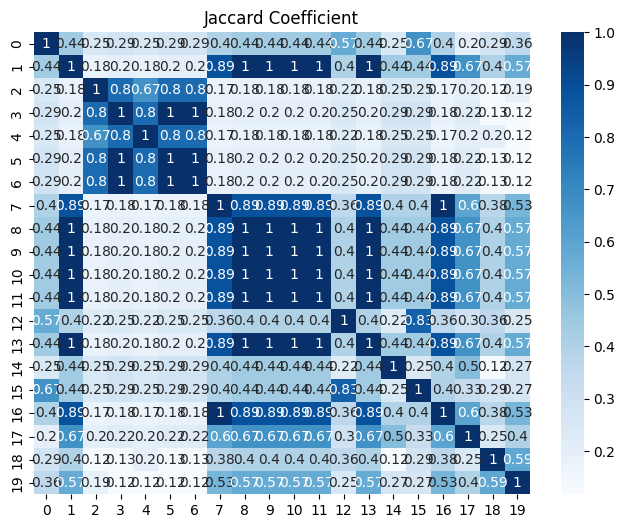

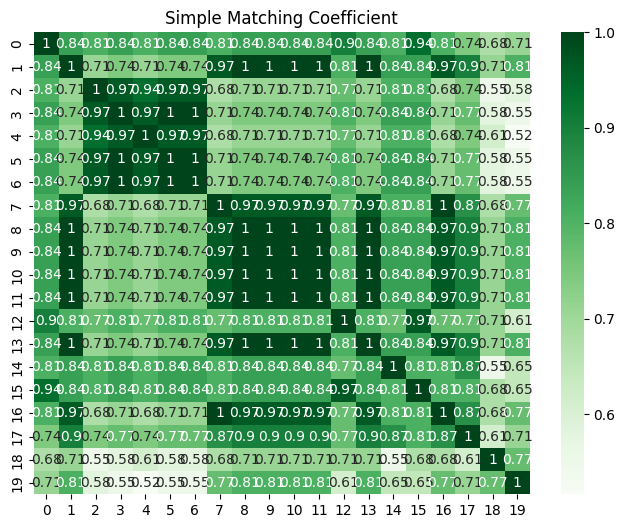

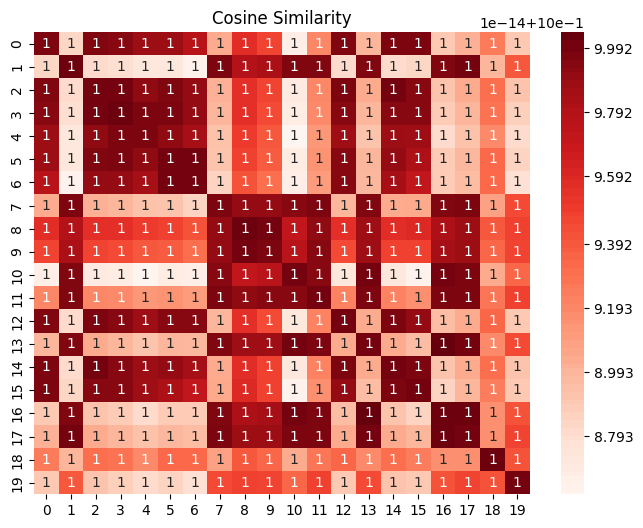

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Load dataset
df = pd.read_excel("Downloads/Lab Session Data (1).xlsx",
                   sheet_name="thyroid0387_UCI")

# Convert binary values
df = df.replace({
    't': 1,
    'f': 0,
    'T': 1,
    'F': 0,
    '?': np.nan
})

# Convert remaining categorical columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]

# Fill missing values
df = df.fillna(0)

# First 20 observations
data = df.iloc[:20]

# Binary data for JC and SMC
binary = (data > 0).astype(int)

n = len(binary)

JC = np.zeros((n, n))
SMC = np.zeros((n, n))
COS = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        v1 = binary.iloc[i].values
        v2 = binary.iloc[j].values

        f11 = np.sum((v1 == 1) & (v2 == 1))
        f10 = np.sum((v1 == 1) & (v2 == 0))
        f01 = np.sum((v1 == 0) & (v2 == 1))
        f00 = np.sum((v1 == 0) & (v2 == 0))

        # Jaccard
        if (f11 + f10 + f01) != 0:
            JC[i][j] = f11 / (f11 + f10 + f01)

        # Simple Matching
        SMC[i][j] = (f11 + f00) / (f11 + f10 + f01 + f00)

        # Cosine Similarity
        a = data.iloc[i].values
        b = data.iloc[j].values

        if np.linalg.norm(a) != 0 and np.linalg.norm(b) != 0:
            COS[i][j] = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Heatmap - Jaccard
plt.figure(figsize=(8,6))
sns.heatmap(JC, annot=True, cmap="Blues")
plt.title("Jaccard Coefficient")
plt.show()

# Heatmap - SMC
plt.figure(figsize=(8,6))
sns.heatmap(SMC, annot=True, cmap="Greens")
plt.title("Simple Matching Coefficient")
plt.show()

# Heatmap - Cosine Similarity
plt.figure(figsize=(8,6))
sns.heatmap(COS, annot=True, cmap="Reds")
plt.title("Cosine Similarity")
plt.show()

In [12]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("Downloads/Lab Session Data (1).xlsx",
                   sheet_name="thyroid0387_UCI")

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Fill missing values
for col in df.columns:

    if pd.api.types.is_numeric_dtype(df[col]):

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((df[col] < lower) | (df[col] > upper)).sum()

        if outliers > 0:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mean())

    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values After Imputation:")
print(df.isnull().sum())

Missing Values After Imputation:
Record ID                    0
age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
TBG measured                 0
TBG                          0
referral source              0
Condition                    0
dtype:

In [13]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("Downloads/Lab Session Data (1).xlsx",
                   sheet_name="thyroid0387_UCI")

# Replace '?' with NaN
df = df.replace('?', np.nan)
# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Apply Min-Max Normalization
for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()

    if max_val != min_val:
        df[col] = (df[col] - min_val) / (max_val - min_val)

print("Normalized Dataset (First 5 Rows):")
print(df.head())

print("\nSummary of Normalized Data:")
print(df[numeric_cols].describe())

Normalized Dataset (First 5 Rows):
      Record ID       age sex on thyroxine query on thyroxine  \
0  0.000000e+00  0.000427   F            f                  f   
1  3.410871e-08  0.000427   F            f                  f   
2  9.891527e-07  0.000610   F            f                  f   
3  6.934301e-05  0.000534   F            f                  f   
4  6.937712e-05  0.000473   F            f                  f   

  on antithyroid medication sick pregnant thyroid surgery I131 treatment  ...  \
0                         f    f        f               f              f  ...   
1                         f    f        f               f              f  ...   
2                         f    f        f               f              f  ...   
3                         f    f        f               f              f  ...   
4                         f    f        f               f              f  ...   

  TT4 measured       TT4 T4U measured T4U FTI measured FTI TBG measured  \
0           